In [1]:
import sys
sys.path.insert(0, '.')
sys.path.insert(0, '..')
import config
import re
import pandas as pd
import numpy as np
from pipeline import data_prep, plots
from pipeline.benchmark import deseq2_path, gene_level_compare, rescued_genes

## PyDESeq2 Benchmark — within-study Disease vs HC
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from scipy.sparse import issparse
import gseapy as gp

In [2]:
dd = data_prep.load_disease_filtered()

## GET PyDeSEQ2 Result

### DESeq2

In [8]:
DESEQ2_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_results'
DESEQ2_DIR.mkdir(parents=True, exist_ok=True)
MP = config.MODELING_PARAMS
_adata = dd.adata
if _adata.raw is not None:
    try:
        _raw_X = _adata.raw[:, _adata.var_names].X
        raw_counts_full = _raw_X.toarray() if issparse(_raw_X) else np.asarray(_raw_X)
    except Exception:
        raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
else:
    raw_counts_full = _adata.X.toarray() if issparse(_adata.X) else np.asarray(_adata.X)
raw_counts_full = np.round(raw_counts_full).astype(np.int64)

obs_names_list = _adata.obs_names.tolist()
obs2idx = {n: i for i, n in enumerate(obs_names_list)}
gene_ids = _adata.var_names.tolist()
id2sym_map = dict(zip(_adata.var_names, _adata.var['GeneName']))
name2pheno_ood = dict(zip(dd.dis_names, dd.dis_pheno))
unique_phenos_ood = sorted(np.unique(dd.dis_pheno))
deseq2_computed = {}

In [9]:
for phenotype in unique_phenos_ood:
    out_path = config.DESEQ2_RESULTS_DIR / f'deseq2_{phenotype.replace("/","_").strip()}.csv'
    if out_path.exists():
        print(f'[{phenotype}] loading existing -> {out_path.name}')
        deseq2_computed[phenotype] = pd.read_csv(out_path)
        continue

    dis_names_ph = [n for n, ph in name2pheno_ood.items() if ph == phenotype]
    if len(dis_names_ph) < 2:
        print(f'[{phenotype}] skip: n_disease={len(dis_names_ph)} < 2')
        continue

    dis_obs = _adata.obs.loc[dis_names_ph]
    authors = dis_obs['Author'].unique().tolist()

    hc_mask = dd.is_hc & _adata.obs['Author'].isin(authors)
    hc_names_ph = _adata.obs_names[hc_mask].tolist()
    if len(hc_names_ph) < 2:
        print(f'[{phenotype}] skip: n_hc={len(hc_names_ph)} < 2 (authors={authors})')
        continue

    sample_names = dis_names_ph + hc_names_ph
    row_idx = [obs2idx[n] for n in sample_names]
    counts_arr = raw_counts_full[row_idx, :]
    counts_df = pd.DataFrame(counts_arr, index=sample_names, columns=gene_ids)
    counts_df = counts_df.loc[:, counts_df.sum(axis=0) >= 10]

    condition = ['Disease'] * len(dis_names_ph) + ['HC'] * len(hc_names_ph)
    author_raw = (dis_obs['Author'].tolist() +
                  _adata.obs.loc[hc_names_ph, 'Author'].tolist())
    author_clean = [re.sub(r'[^A-Za-z0-9]+', '_', a).strip('_') for a in author_raw]

    metadata = pd.DataFrame({
        'condition': pd.Categorical(condition, categories=['HC', 'Disease']),
        'Author_clean': author_clean,
    }, index=sample_names)

    n_authors = len(set(author_clean))
    design = '~Author_clean + condition' if n_authors > 1 else '~condition'

    try:
        inference = DefaultInference(n_cpus=4)
        dds = DeseqDataSet(
            counts=counts_df,
            metadata=metadata,
            design=design,
            refit_cooks=True,
            inference=inference,
        )
        dds.deseq2()

        ds = DeseqStats(dds, contrast=['condition', 'Disease', 'HC'], inference=inference)
        ds.summary()

        res = ds.results_df.copy()
        res.index.name = 'ensg'
        res = res.reset_index()
        res['symbol'] = res['ensg'].map(id2sym_map).fillna(res['ensg'])

        res.to_csv(out_path, index=False)
        deseq2_computed[phenotype] = res

        n_sig = int((res['padj'].dropna() < 0.05).sum())
        print(f'[{phenotype}] n_dis={len(dis_names_ph)} n_hc={len(hc_names_ph)} '
              f'design={repr(design)}  sig={n_sig}')
    except Exception as e:
        print(f'[{phenotype}] ERROR -- {e}')

print(f'Done: {len(deseq2_computed)} / {len(unique_phenos_ood)} phenotypes computed')

[CAD_HF+] loading existing -> deseq2_CAD_HF+.csv
[CAD_HF-] loading existing -> deseq2_CAD_HF-.csv
[Colorectal Cancer] loading existing -> deseq2_Colorectal Cancer.csv
[Esophagus Cancer (Chen)] loading existing -> deseq2_Esophagus Cancer (Chen).csv
[HIV] loading existing -> deseq2_HIV.csv
[HIV + Tuberculosis] loading existing -> deseq2_HIV + Tuberculosis.csv
[ICI-m] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[ICI-treated Cancer] skip: n_hc=0 < 2 (authors=['Raissadati et al.'])
[Liver Cancer (Chen)] loading existing -> deseq2_Liver Cancer (Chen).csv
[Liver Cancer (Roskams-Hieter)] loading existing -> deseq2_Liver Cancer (Roskams-Hieter).csv
[Lung Cancer] loading existing -> deseq2_Lung Cancer.csv
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.04 seconds.

Fitting dispersions...
... done in 2.25 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 2.50 seconds.

Fitting LFCs...
... done in 1.43 seconds.

Calculating cook's distance...
... done in 0.06 seconds.

Replacing 136 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.03 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...
... done in 0.58 seconds.

Fitting size factors...
... done in 0.02 seconds.



Log2 fold change & Wald test p-value: condition Disease vs HC
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003.17   3.589067       -0.183581  0.229745 -0.799064  0.424253   
ENSG00000000005.6    0.334462        0.261187  0.575502  0.453842  0.649943   
ENSG00000000419.15  58.164472        0.118251  0.069847  1.693013  0.090453   
ENSG00000000457.15  49.258697        0.148398  0.076169  1.948286  0.051381   
ENSG00000000460.18  87.849998       -0.197077  0.125094 -1.575422  0.115159   
...                       ...             ...       ...       ...       ...   
ENSG00000310560.2   28.820734        0.200518  0.113734  1.763054  0.077891   
ENSG00000310576.1   10.939527        0.055225  0.118513  0.465986  0.641225   
ENSG00000310579.1    1.335385        0.213469  0.356701  0.598453  0.549538   
ENSG00000310583.1    4.542265       -0.381950  0.210627 -1.813398  0.069770   
ENSG00000310592.1    0.133442        0.030811  1.104525  0.027895  0.

Fitting dispersions...
... done in 2.40 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 2.38 seconds.

Fitting LFCs...
... done in 2.68 seconds.

Calculating cook's distance...
... done in 0.05 seconds.

Replacing 4869 outlier genes.

Fitting dispersions...
... done in 0.61 seconds.

Fitting MAP dispersions...
... done in 0.55 seconds.

Fitting LFCs...
... done in 0.88 seconds.

Running Wald tests...
... done in 0.45 seconds.

Fitting size factors...
... done in 0.02 seconds.



Log2 fold change & Wald test p-value: condition Disease vs HC
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003.17   12.243346        0.878811  1.159398  0.757989  0.448457   
ENSG00000000005.6     1.131795       -3.659623  3.430462 -1.066802  0.286061   
ENSG00000000419.15  108.723113       -1.102649  0.418273 -2.636193  0.008384   
ENSG00000000457.15  110.074081       -0.343330  0.480338 -0.714768  0.474752   
ENSG00000000460.18   71.605109       -1.442502  0.767669 -1.879068  0.060235   
...                        ...             ...       ...       ...       ...   
ENSG00000310560.2    53.856032       -0.365626  0.700299 -0.522100  0.601601   
ENSG00000310576.1    46.691426       -0.524191  0.776278 -0.675261  0.499510   
ENSG00000310579.1     1.933591        1.209714  2.341144  0.516719  0.605352   
ENSG00000310583.1     2.363909       -4.459891  3.010649 -1.481372  0.138508   
ENSG00000310592.1     0.118288       -2.005294  4.358403 -

...

Fitting dispersions...
... done in 2.29 seconds.

Fitting dispersion trend curve...
... done in 0.19 seconds.

Fitting MAP dispersions...
... done in 4.83 seconds.

Fitting LFCs...
... done in 1.86 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 1832 outlier genes.

Fitting dispersions...
... done in 0.20 seconds.

Fitting MAP dispersions...
... done in 0.21 seconds.

Fitting LFCs...
... done in 0.21 seconds.

Running Wald tests...
... done in 0.44 seconds.

Fitting size factors...


Log2 fold change & Wald test p-value: condition Disease vs HC
                      baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003.17   13.475067       -1.665614  0.540637 -3.080840  0.002064   
ENSG00000000005.6     1.848180       -3.418030  1.598663 -2.138055  0.032512   
ENSG00000000419.15   56.727545       -1.424990  0.306601 -4.647705  0.000003   
ENSG00000000457.15   47.387317       -1.414337  0.292539 -4.834696  0.000001   
ENSG00000000460.18  111.824874        0.556996  0.235300  2.367173  0.017925   
...                        ...             ...       ...       ...       ...   
ENSG00000310525.1     6.115110        1.297962  1.316601  0.985844  0.324210   
ENSG00000310560.2    26.213309       -2.069313  0.435743 -4.748927  0.000002   
ENSG00000310576.1    19.925435       -2.106417  0.476200 -4.423384  0.000010   
ENSG00000310579.1     1.898440       -2.317287  1.474911 -1.571137  0.116151   
ENSG00000310583.1     2.532901        1.139818  0.993956  

... done in 0.03 seconds.

Fitting dispersions...
... done in 2.54 seconds.

Fitting dispersion trend curve...
... done in 0.18 seconds.

Fitting MAP dispersions...
... done in 2.63 seconds.

Fitting LFCs...
... done in 1.95 seconds.

Calculating cook's distance...
... done in 0.07 seconds.

Replacing 248 outlier genes.

Fitting dispersions...
... done in 0.05 seconds.

Fitting MAP dispersions...
... done in 0.04 seconds.

Fitting LFCs...
... done in 0.04 seconds.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Disease vs HC
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
ENSG00000000003.17   2.585513       -0.437986  0.336543 -1.301426  0.193113   
ENSG00000000005.6    0.209814       -0.518829  0.719024 -0.721574  0.470557   
ENSG00000000419.15  36.795221        0.069277  0.109951  0.630066  0.528651   
ENSG00000000457.15  23.342290       -0.223379  0.122018 -1.830703  0.067145   
ENSG00000000460.18  14.822951       -0.131520  0.220549 -0.596332  0.550953   
...                       ...             ...       ...       ...       ...   
ENSG00000310560.2   14.819663       -0.155943  0.195957 -0.795802  0.426147   
ENSG00000310576.1    4.579609        0.354675  0.181255  1.956773  0.050374   
ENSG00000310579.1    1.196282       -0.436330  0.362016 -1.205278  0.228096   
ENSG00000310583.1    1.003486       -0.183325  0.364562 -0.502863  0.615060   
ENSG00000310592.1    0.174957        0.130781  0.713465  0.183304  0.

... done in 0.48 seconds.



### DESeq2 GSEA Result

In [10]:
# Requires deseq2_computed and deseq2_path() from the PyDESeq2 cell above.
GSEA_DIR = config.MODELING_DIR / 'Benchmark' / 'deseq2_gsea'

deseq2_results = {}
all_phenos_for_gsea = list(deseq2_computed.keys()) if deseq2_computed else unique_phenos_ood

for phenotype in all_phenos_for_gsea:
    if phenotype in deseq2_computed:
        res_df = deseq2_computed[phenotype].copy()
    else:
        path = config.DESEQ2_RESULTS_DIR / f'deseq2_{phenotype.replace("/","_").strip()}.csv'
        if not path.exists():
            print(f'[{phenotype}] no DESeq2 result -- skip GSEA')
            continue
        res_df = pd.read_csv(path)

    out_csv = GSEA_DIR / f"gsea_result_{phenotype.replace('/', '_')}.csv"
    if out_csv.exists():
        print(f'[{phenotype}] loading existing GSEA')
        deseq2_results[phenotype] = pd.read_csv(out_csv)
        continue

    res_df['stat'] = res_df['stat'].fillna(0.0)
    res_df['abs_stat'] = res_df['stat'].abs()
    res_df = (res_df.sort_values('abs_stat', ascending=False)
                    .drop_duplicates('symbol')
                    .drop(columns='abs_stat'))

    rnk = (res_df[['symbol', 'stat']]
           .rename(columns={'symbol': 'gene', 'stat': 'score'})
           .sort_values('score', ascending=False)
           .reset_index(drop=True))

    try:
        res = gp.prerank(
            rnk=rnk, gene_sets=MP['gsea_gene_sets'], outdir=None,
            min_size=10, max_size=500,
            permutation_num=MP['gsea_perm'], seed=MP['gsea_seed'], verbose=False)
        sig = res.res2d[res.res2d['FDR q-val'] < MP['gsea_fdr_thr']].copy()
        sig.to_csv(out_csv, index=False)
        deseq2_results[phenotype] = sig
        sig['NES'] = pd.to_numeric(sig['NES'], errors='coerce')
        n_up = int((sig['NES'] > 0).sum())
        n_dn = int((sig['NES'] < 0).sum())
        print(f'[{phenotype}] {len(sig):4d} sig  (NES>0: {n_up:3d}  NES<0: {n_dn:3d})')
    except Exception as e:
        print(f'[{phenotype}] GSEA ERROR -- {e}')

print(f'Done: {len(deseq2_results)} phenotypes with GSEA results')

deseq2_fig_dir = GSEA_DIR / 'gsea_dotplot'
plots.plot_gsea_dotplots(deseq2_results, fig_dir=deseq2_fig_dir)

[CAD_HF+] loading existing GSEA
[CAD_HF-] loading existing GSEA
[Colorectal Cancer] loading existing GSEA
[Esophagus Cancer (Chen)] loading existing GSEA
[HIV] loading existing GSEA
[HIV + Tuberculosis] loading existing GSEA
[Liver Cancer (Chen)] loading existing GSEA
[Liver Cancer (Roskams-Hieter)] loading existing GSEA
[Lung Cancer] loading existing GSEA
[ME/CFS] loading existing GSEA
[MGUS] loading existing GSEA
[MM] loading existing GSEA
[Other Cancer] loading existing GSEA
[Pancreatic Cancer (Moore)] loading existing GSEA
[Pancreatitis] loading existing GSEA
[Pre-eclampsia] loading existing GSEA
[Stomach Cancer] loading existing GSEA
[Tuberculosis] loading existing GSEA
Done: 18 phenotypes with GSEA results
[CAD_HF+] GSEA Plots generated successfully.
[CAD_HF-] GSEA Plots generated successfully.
[Colorectal Cancer] GSEA Plots generated successfully.
[Esophagus Cancer (Chen)] GSEA Plots generated successfully.
[HIV] GSEA Plots generated successfully.
[HIV + Tuberculosis] GSEA Plots

## DESeq2 Benchmark — Analysis 1: Genes Rescued by Normative Modeling

In [11]:
unique_phenos = pd.Series(dd.dis_pheno).unique()

Esophagus Cancer (Chen)
genes compared: 18614  |  DESeq2-excluded: 35
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Esophagus_Cancer_(Chen).csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


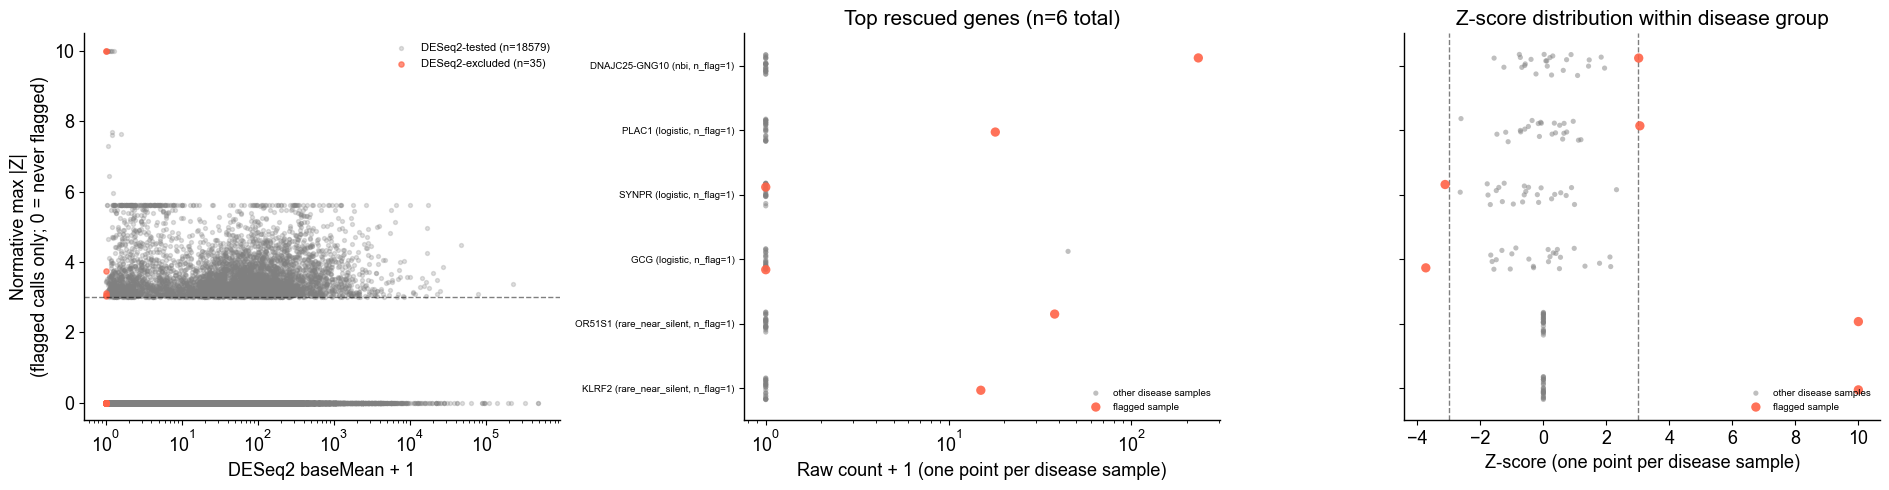

Lung Cancer
genes compared: 18646  |  DESeq2-excluded: 40
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Lung_Cancer.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


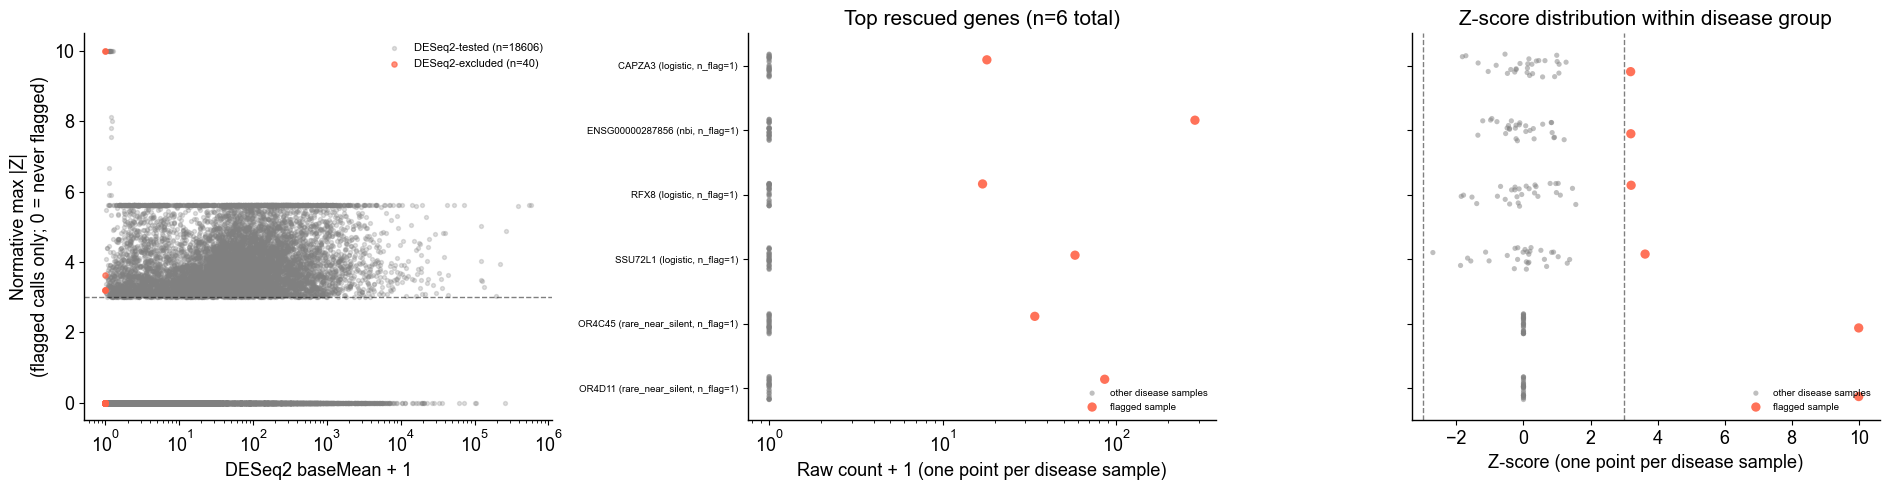

Liver Cancer (Chen)
genes compared: 18538  |  DESeq2-excluded: 68
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Liver_Cancer_(Chen).csv


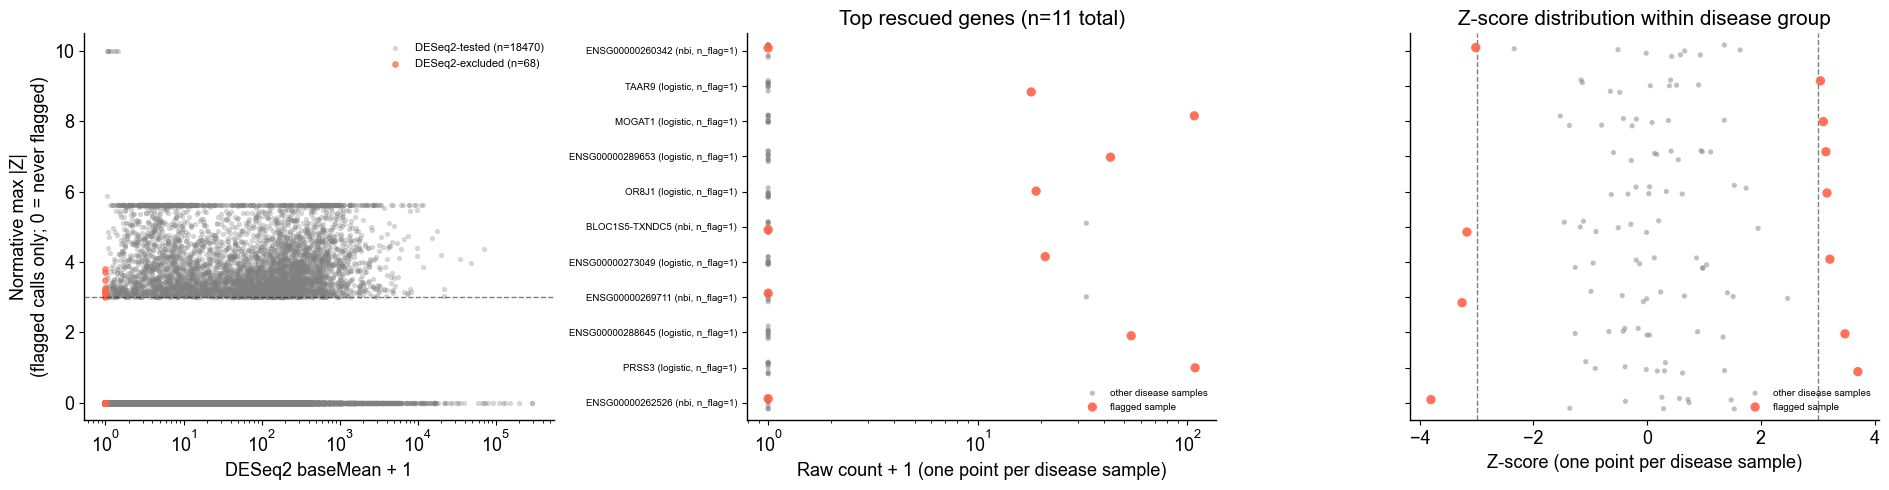

Stomach Cancer
genes compared: 18545  |  DESeq2-excluded: 37
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Stomach_Cancer.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


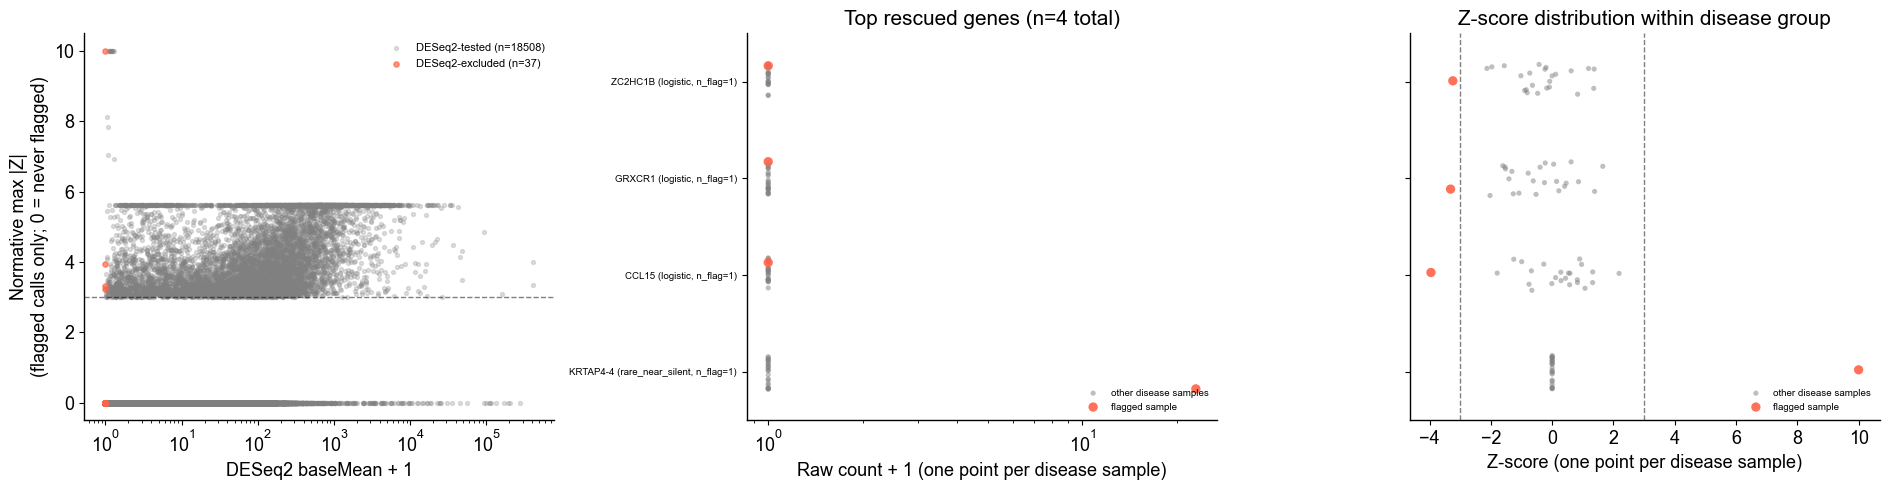

Colorectal Cancer
genes compared: 18408  |  DESeq2-excluded: 46
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Colorectal_Cancer.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


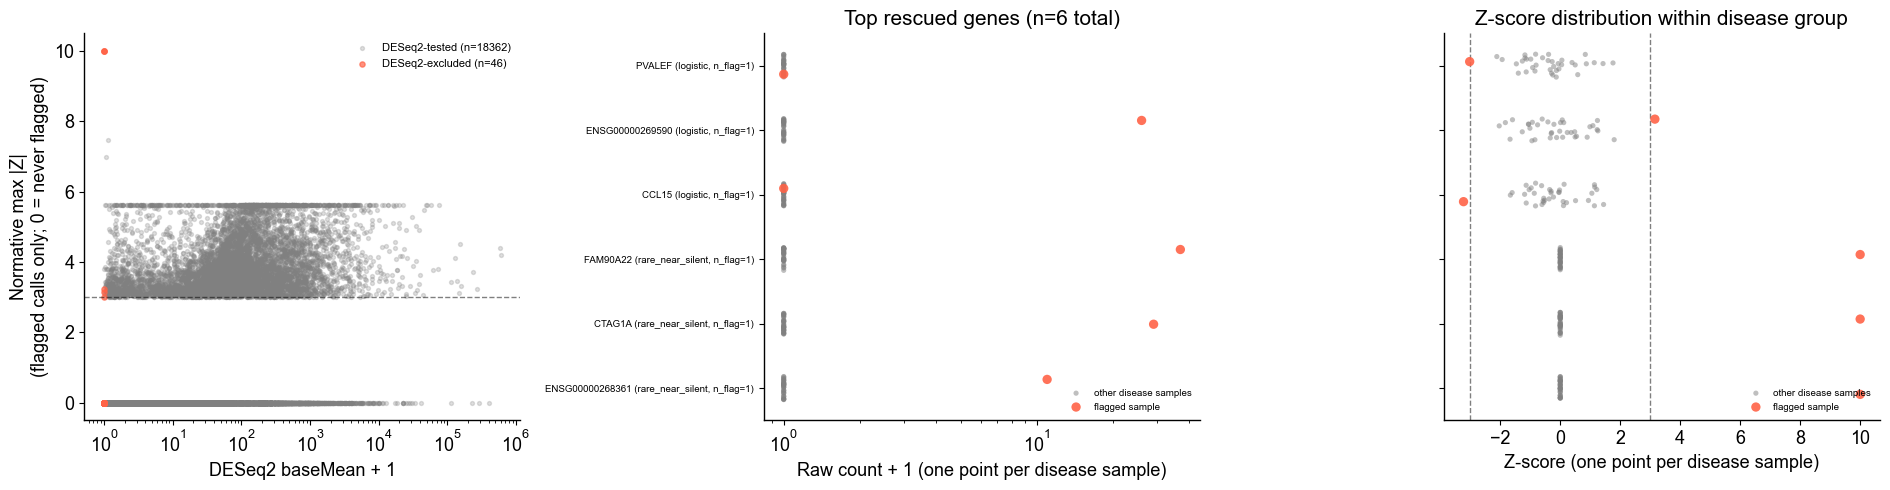

MM
genes compared: 18239  |  DESeq2-excluded: 32
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_MM.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


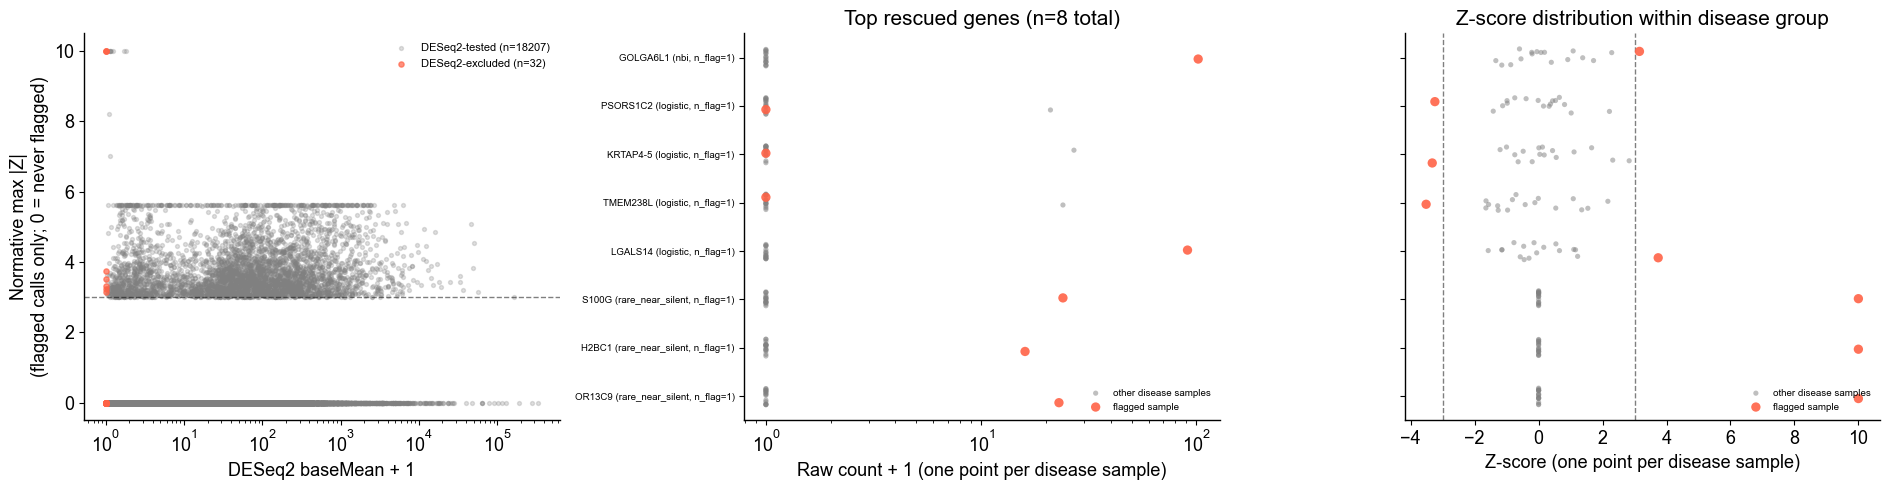

MGUS
genes compared: 18069  |  DESeq2-excluded: 40
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_MGUS.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


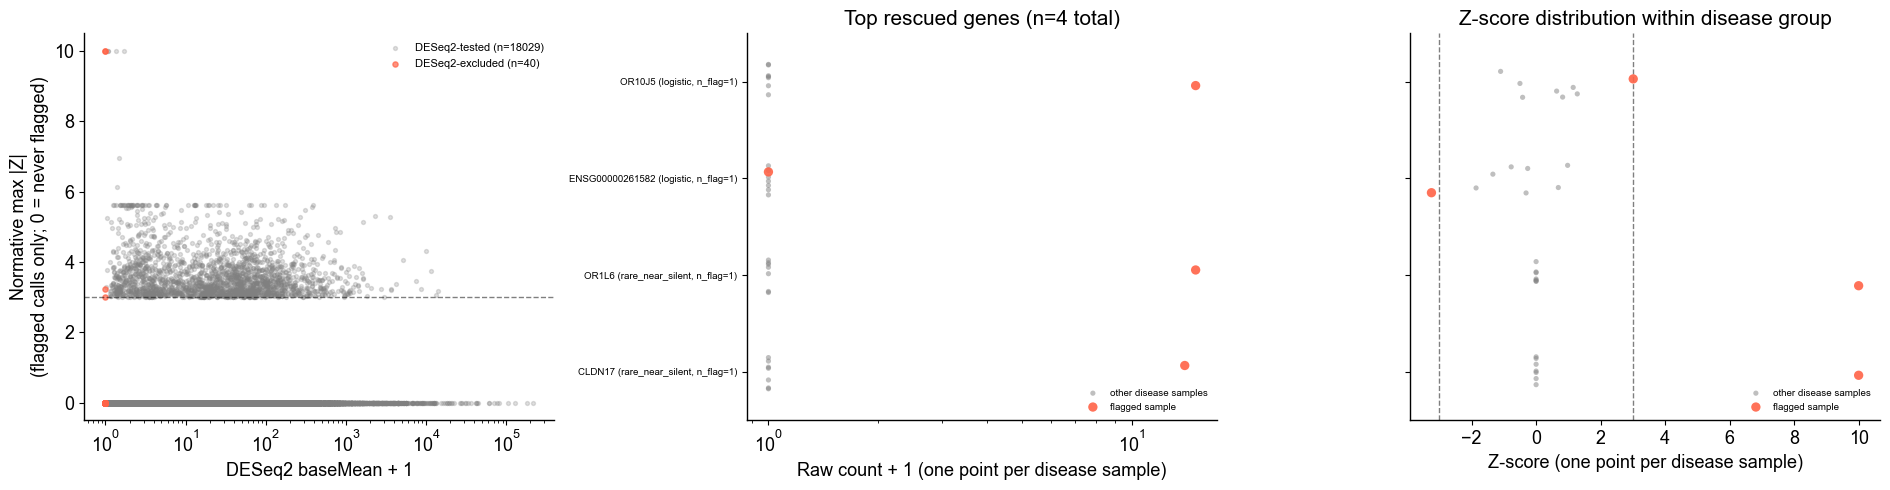

Liver Cancer (Roskams-Hieter)
genes compared: 18466  |  DESeq2-excluded: 44
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Liver_Cancer_(Roskams-Hieter).csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


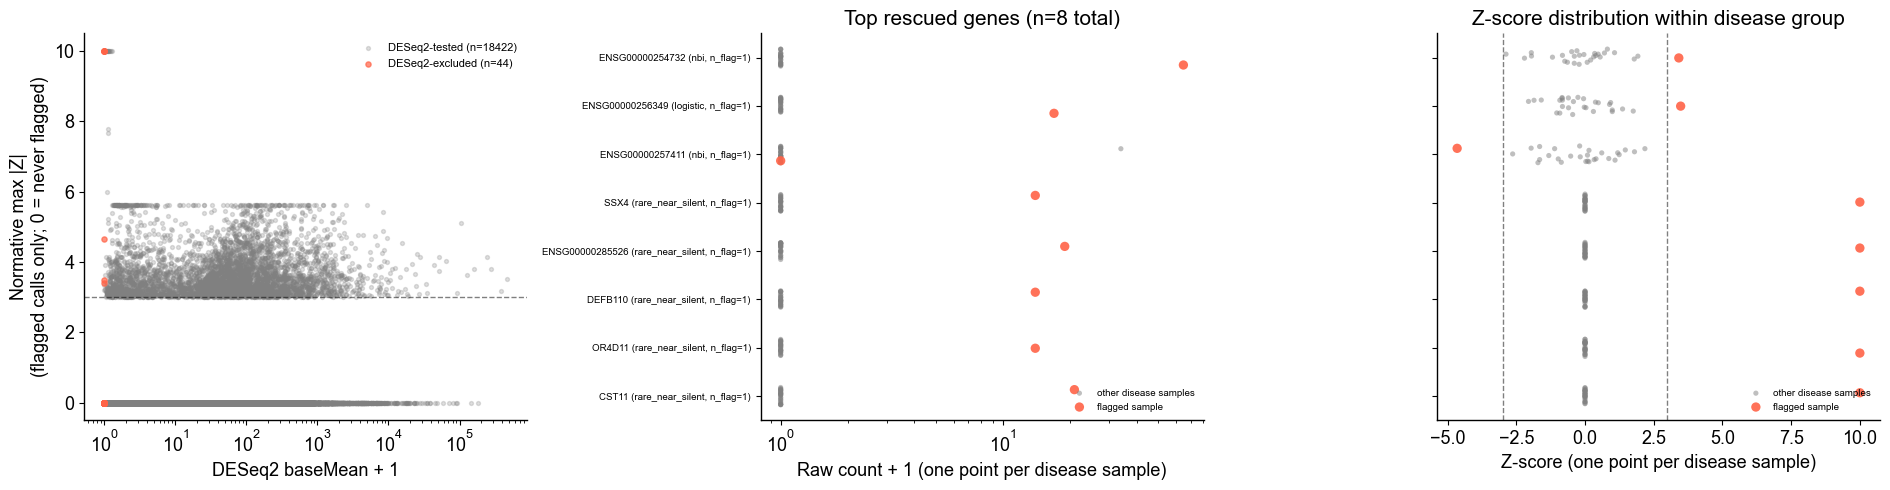

Pre-eclampsia
genes compared: 18805  |  DESeq2-excluded: 70
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pre-eclampsia.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


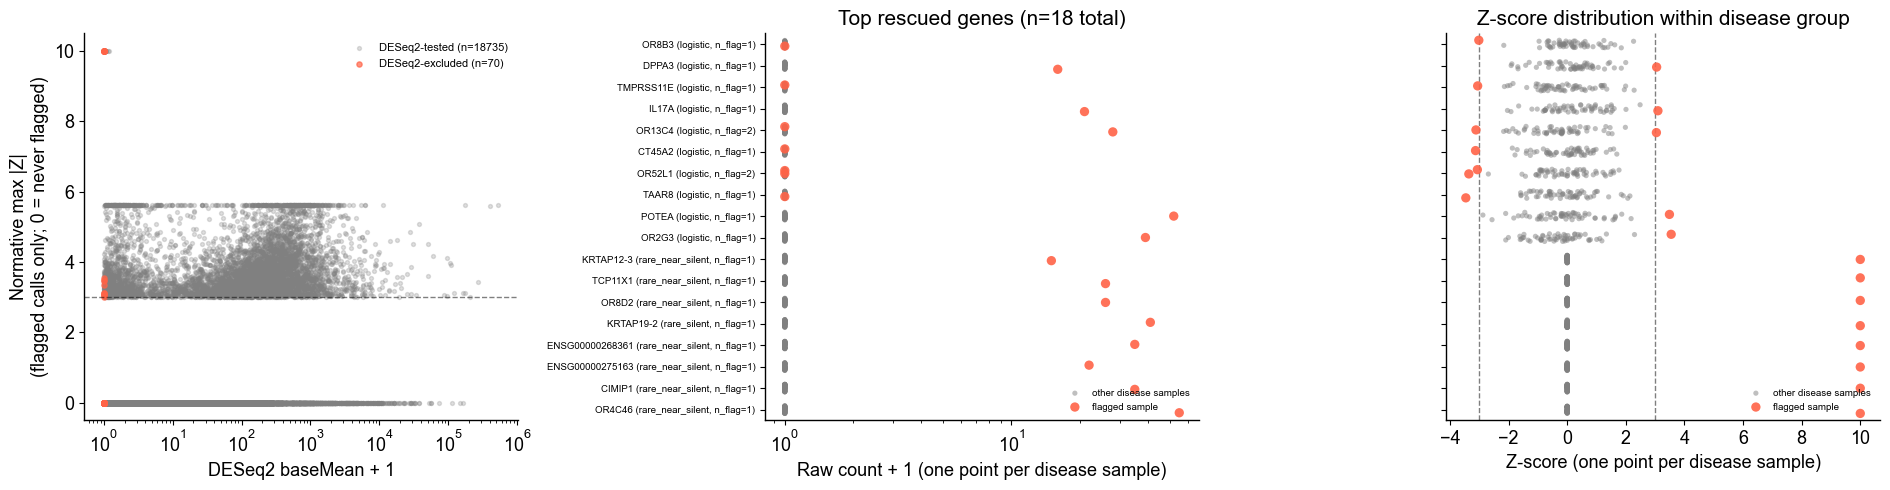

CAD_HF-
genes compared: 18660  |  DESeq2-excluded: 1
No Rescued Genes in CAD_HF-, Skipped.
CAD_HF+
genes compared: 18758  |  DESeq2-excluded: 1
No Rescued Genes in CAD_HF+, Skipped.
Pancreatitis
genes compared: 18582  |  DESeq2-excluded: 112
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pancreatitis.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


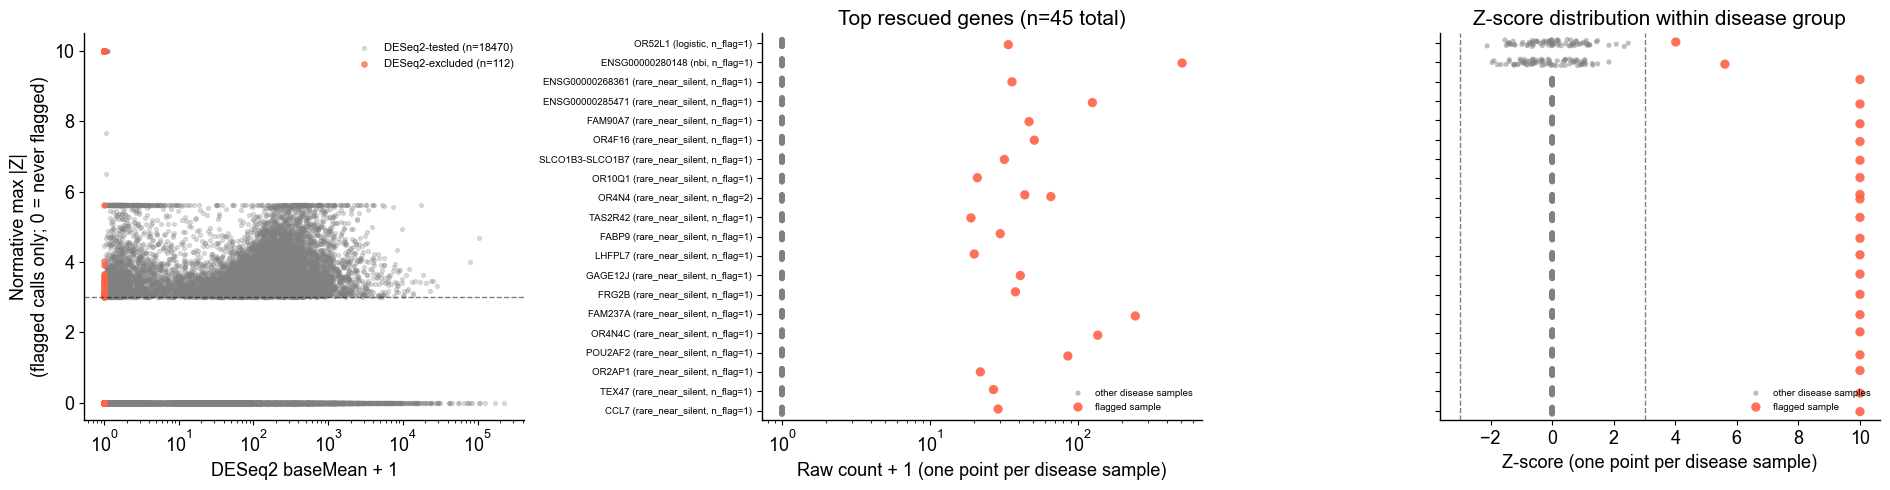

Other Cancer
genes compared: 18016  |  DESeq2-excluded: 140
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Other_Cancer.csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


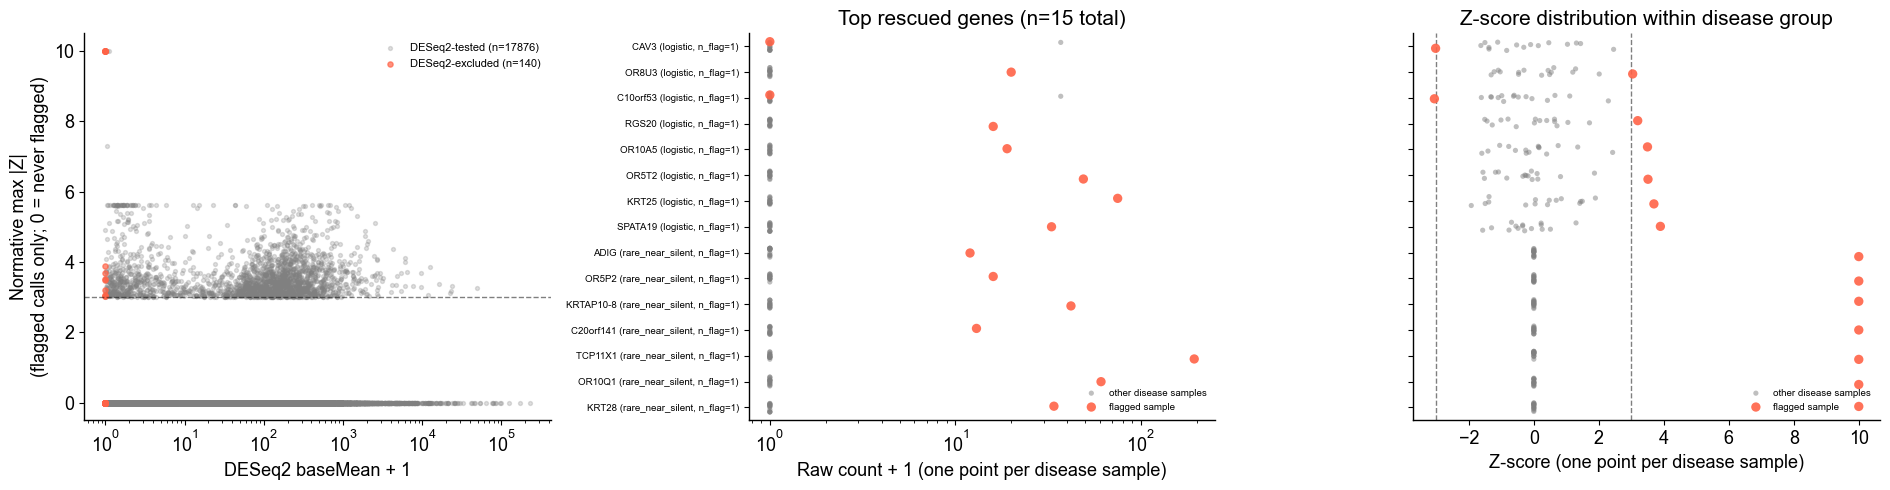

Pancreatic Cancer (Moore)
genes compared: 18651  |  DESeq2-excluded: 121
saved -> /project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/rescued_genes_Pancreatic_Cancer_(Moore).csv
Engine loaded from /project/cfRNA_NormativeModeling/Modeling/../Modeling/engine_state/  (19538 fitted genes)
Loaded reference: 559 rare genes


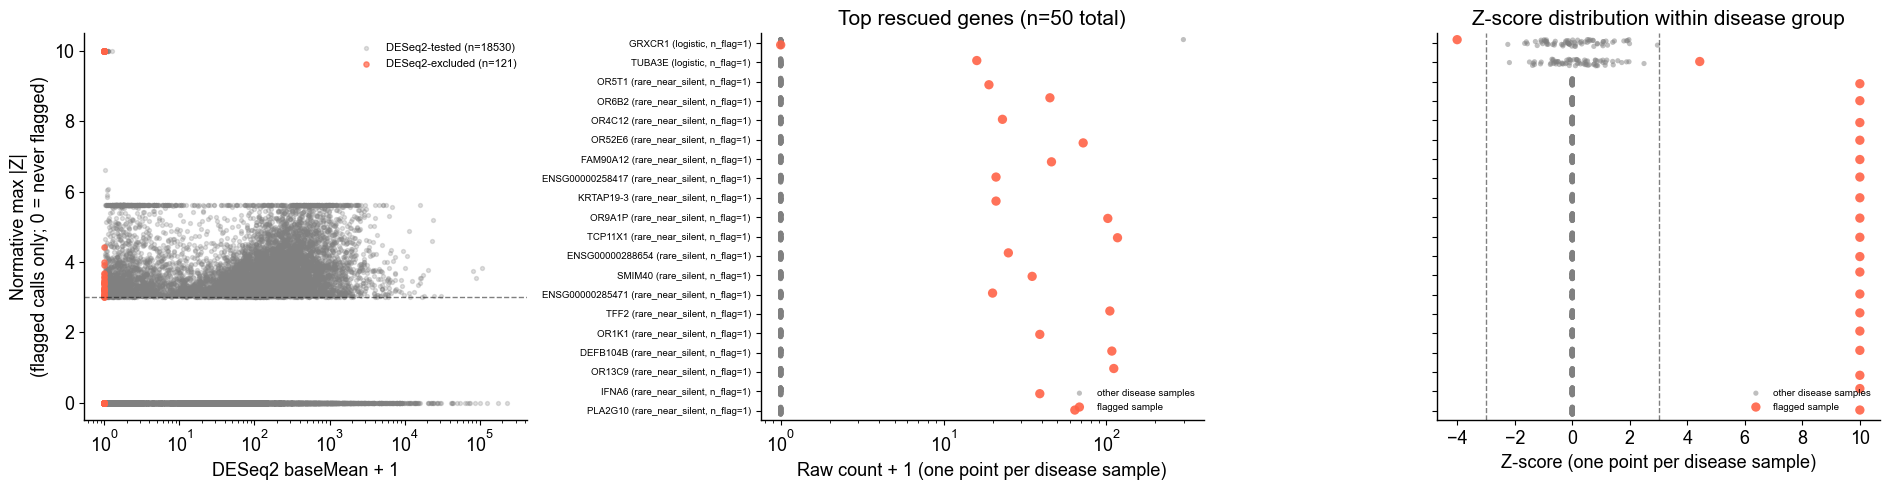

HIV + Tuberculosis
genes compared: 17642  |  DESeq2-excluded: 0
No Rescued Genes in HIV + Tuberculosis, Skipped.
Tuberculosis
genes compared: 18549  |  DESeq2-excluded: 0
No Rescued Genes in Tuberculosis, Skipped.
HIV
genes compared: 17538  |  DESeq2-excluded: 1
No Rescued Genes in HIV, Skipped.
ME/CFS


FileNotFoundError: [Errno 2] No such file or directory: '/project/cfRNA_NormativeModeling/Modeling/../Modeling/Benchmark/deseq2_results/deseq2_ME/CFS.csv'

In [12]:
for PHENOTYPE in unique_phenos : 
    print(PHENOTYPE)
    if not (config.DESEQ2_RESULTS_DIR / f'deseq2_{PHENOTYPE.replace("/","_").strip()}.csv').exists():
        print(f"No DESeq2 result for {PHENOTYPE}, Skipped.")
        continue

    merged = gene_level_compare(dd, PHENOTYPE)
    print(f"genes compared: {len(merged)}  |  DESeq2-excluded: {merged['excluded'].sum()}")
    rescued = rescued_genes(merged)
    if len(rescued) == 0:
        print(f"No Rescued Genes in {PHENOTYPE}, Skipped.")
        continue 

    out_path = config.BENCHMARK_DIR / f"rescued_genes_{PHENOTYPE.replace(' ', '_').replace('/', '_')}.csv"
    rescued.to_csv(out_path, index=False)
    print(f'saved -> {out_path}')
    _ = plots.plot_rescued_genes(merged, rescued, PHENOTYPE, dd=dd)